# Risk-Premium PCA: Pricing Information in Latent Factors

**Docker image**: `ml4t`

**Chapter 14: Latent Factor Models**

Principal component analysis favors directions with high return variance.
Risk-Premium PCA (RP-PCA; Lettau and Pelger, 2020) also rewards directions
that explain the cross-section of mean returns:

$$M_\kappa=\Sigma+\kappa\,\bar r\bar r^{\top}.$$

The top eigenvectors of $M_\kappa$ define static factor portfolios. At
$\kappa=0$, the estimator is ordinary covariance PCA. Positive values tilt
Stage 1 toward priced directions that may have modest variance.

**Learning objectives**

- implement RP-PCA from the modified covariance matrix;
- separate training mean fit from evaluation covariance reconstruction;
- compare loading spaces without relying on arbitrary factor signs; and
- produce one-day-ahead factor and asset forecasts with walk-forward updates.

**Evaluation contract**: the loading map is fit before the temporal split.
At each evaluation decision, the current return and its projected factor are
observable; only then is the next factor premium forecast. The evaluation window is a
teaching demonstration: it is neither a holdout kept untouched for a final measurement
nor a set used to choose between models. The pre-specified forecast model uses
$\kappa=10$.

**Universe limitation**: the source is a curated present-day ETF set, so the
panel is suitable for method exposition but not a survivorship-free historical
strategy claim. Eligibility is determined from the training window only, and
no missing return is imputed.

**Prerequisites**: [`01_pca_equity_sectors`](01_pca_equity_sectors.ipynb) and
[`04_ipca`](04_ipca.ipynb)

**Book section**: Section 14.5, "Finding priced factors with risk-premium PCA"

**Next**: [`06_conditional_autoencoder`](06_conditional_autoencoder.ipynb)
replaces the static linear loading map with a neural network.

## 1. Setup

In [1]:
"""Estimate RP-PCA factors and evaluate correctly aligned walk-forward forecasts."""

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from ml4t.diagnostic.metrics.uncertainty import compute_ic_uncertainty
from scipy.linalg import eigh

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import (
    COLORS,
    FIGSIZE,
    add_message_title,
    ml4t_palette,
    show_with_alt,
    zero_line,
)

In [2]:
N_FACTORS = 5
KAPPAS = [0.0, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]
FOCUS_KAPPA = 10.0
TRAIN_FRAC = 0.7
START_DATE = "2006-01-01"
END_DATE = "2024-12-31"
MAX_SYMBOLS = 0
EWMA_HALF_LIFE = 60
N_BOOTSTRAP = 2_000
SEED = 42

set_global_seeds(SEED)

## 2. Build a balanced, training-defined panel

Computing returns before the pivot avoids treating a missing price as a zero
return. The initial wide panel retains nulls so eligibility can distinguish
a real zero from a pre-inception observation.

In [3]:
etf_data = load_etfs(start_date=START_DATE, end_date=END_DATE)
etf_returns = (
    etf_data.sort(["symbol", "timestamp"])
    .with_columns(pl.col("close").pct_change().over("symbol").alias("return"))
    .drop_nulls(subset=["return"])
)
return_wide = etf_returns.pivot(
    on="symbol",
    index="timestamp",
    values="return",
).sort("timestamp")

A symbol is eligible only if it has an observed return on every training
date. The rule is fixed before evaluation. The resulting 59 ETFs also happen
to have complete evaluation histories, which we verify rather than assume.

In [4]:
def training_complete_symbols(
    wide_returns: pl.DataFrame,
    train_end: int,
    max_symbols: int = 0,
) -> list[str]:
    """Select alphabetically stable symbols with complete training histories."""
    candidates = [column for column in wide_returns.columns if column != "timestamp"]
    null_counts = wide_returns[:train_end].select(candidates).null_count().row(0, named=True)
    eligible = sorted(symbol for symbol, count in null_counts.items() if count == 0)
    return eligible[:max_symbols] if max_symbols > 0 else eligible

In [5]:
panel_size = return_wide.height
split_index = int(panel_size * TRAIN_FRAC)
symbols = training_complete_symbols(return_wide, split_index, MAX_SYMBOLS)
balanced = return_wide.select(["timestamp", *symbols])
evaluation_nulls = balanced[split_index:].select(symbols).null_count().sum_horizontal().item()
if evaluation_nulls:
    raise ValueError(f"Evaluation panel contains {evaluation_nulls} missing returns")

dates = balanced["timestamp"].to_numpy()
returns = balanced.select(symbols).to_numpy().astype(np.float64)
train_returns = returns[:split_index]
decision_returns = returns[split_index:-1]
target_returns = returns[split_index + 1 :]
decision_timestamps = dates[split_index:-1]

print(
    f"Balanced panel: {len(returns):,} dates, {len(symbols)} ETFs, "
    f"train={len(train_returns):,}, walk-forward decisions={len(target_returns):,}, "
    f"missing evaluation returns={evaluation_nulls}"
)
print(f"Date range: {dates[0]} to {dates[-1]}")

Balanced panel: 4,780 dates, 59 ETFs, train=3,346, walk-forward decisions=1,433, missing evaluation returns=0
Date range: 2006-01-04 to 2024-12-31


The one-day target alignment is explicit: the current return at each decision
becomes Stage 2 history, while the following row is the evaluation target.
The current row therefore provides the one-period gap between the Stage 1 fit
and the first target.

In [6]:
assert len(decision_returns) == len(target_returns) == len(decision_timestamps)
assert np.isfinite(returns).all()

## 3. Stage 1: fit RP-PCA

The covariance and mean vector are estimated on the training window only.
Eigenvector signs are anchored deterministically because neither signs nor
rotations within a tied eigenspace change the fitted subspace.

In [7]:
def fit_rppca(
    training_returns: np.ndarray,
    n_factors: int,
    kappa: float,
) -> dict[str, np.ndarray | float]:
    """Fit RP-PCA from a centered covariance plus a weighted mean outer product."""
    mean_returns = training_returns.mean(axis=0)
    covariance = np.cov(training_returns, rowvar=False)
    pricing_matrix = covariance + kappa * np.outer(mean_returns, mean_returns)
    eigenvalues, eigenvectors = eigh(pricing_matrix)
    order = np.argsort(eigenvalues)[::-1]
    loadings = eigenvectors[:, order[:n_factors]]
    anchors = np.argmax(np.abs(loadings), axis=0)
    signs = np.sign(loadings[anchors, np.arange(n_factors)])
    signs[signs == 0] = 1
    loadings *= signs
    factors = training_returns @ loadings
    factor_sharpes = factors.mean(axis=0) / factors.std(axis=0, ddof=1) * np.sqrt(252)
    return {
        "kappa": kappa,
        "mean_returns": mean_returns,
        "loadings": loadings,
        "factors": factors,
        "eigenvalues": eigenvalues[order],
        "factor_sharpes": factor_sharpes,
    }

Pricing fit measures how well the loading subspace spans the training mean
vector. Reconstruction share measures how much raw evaluation return energy
the same subspace retains relative to a zero-return reconstruction.

In [8]:
def projection_share(values: np.ndarray, loadings: np.ndarray) -> float:
    """Return the fraction of squared magnitude retained by a projection."""
    projected = values @ loadings @ loadings.T
    denominator = np.mean(values**2)
    return 1.0 - float(np.mean((values - projected) ** 2)) / denominator

In [9]:
def loading_space_distance(reference: np.ndarray, candidate: np.ndarray) -> tuple[float, float]:
    """Return minimum principal cosine and Frobenius projector distance."""
    principal_cosines = np.linalg.svd(reference.T @ candidate, compute_uv=False)
    reference_projection = reference @ reference.T
    candidate_projection = candidate @ candidate.T
    distance = np.linalg.norm(reference_projection - candidate_projection, ord="fro")
    return float(principal_cosines.min()), float(distance)

In [10]:
stage1_models = {kappa: fit_rppca(train_returns, N_FACTORS, kappa) for kappa in KAPPAS}
pca_loadings = stage1_models[0.0]["loadings"]
stage1_results = []
for kappa, model in stage1_models.items():
    pricing_share = projection_share(model["mean_returns"][None, :], model["loadings"])
    reconstruction_share = projection_share(returns[split_index:], model["loadings"])
    minimum_cosine, projector_distance = loading_space_distance(
        pca_loadings,
        model["loadings"],
    )
    average_sharpe = float(np.mean(np.abs(model["factor_sharpes"])))
    stage1_results.append(
        {
            "kappa": kappa,
            "pricing_share": pricing_share,
            "reconstruction_share": reconstruction_share,
            "minimum_cosine": minimum_cosine,
            "projector_distance": projector_distance,
            "average_abs_sharpe": average_sharpe,
        }
    )
    print(
        f"kappa={kappa:>5g}: train mean fit={pricing_share:.3f}, "
        f"evaluation reconstruction={reconstruction_share:.3f}, "
        f"min cosine={minimum_cosine:.3f}, avg |SR|={average_sharpe:.3f}"
    )

kappa=    0: train mean fit=0.845, evaluation reconstruction=0.785, min cosine=1.000, avg |SR|=0.213
kappa=    1: train mean fit=0.846, evaluation reconstruction=0.785, min cosine=1.000, avg |SR|=0.214
kappa=    5: train mean fit=0.848, evaluation reconstruction=0.785, min cosine=1.000, avg |SR|=0.216
kappa=   10: train mean fit=0.850, evaluation reconstruction=0.785, min cosine=1.000, avg |SR|=0.219
kappa=   50: train mean fit=0.872, evaluation reconstruction=0.787, min cosine=0.990, avg |SR|=0.251
kappa=  100: train mean fit=0.912, evaluation reconstruction=0.788, min cosine=0.914, avg |SR|=0.312
kappa=  500: train mean fit=0.998, evaluation reconstruction=0.787, min cosine=0.250, avg |SR|=0.276


The three panels expose the intended tradeoff directly. Increasing $\kappa$
can improve representation of the training mean only by rotating away from
the variance-dominant PCA space, which may sacrifice evaluation reconstruction.

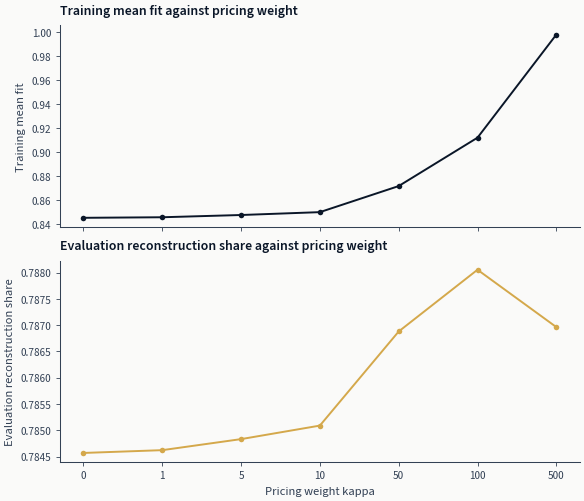

Evaluation reconstruction share ranges 0.7846 to 0.7881 across the kappa grid; training mean fit ranges 0.8452 to 0.9978


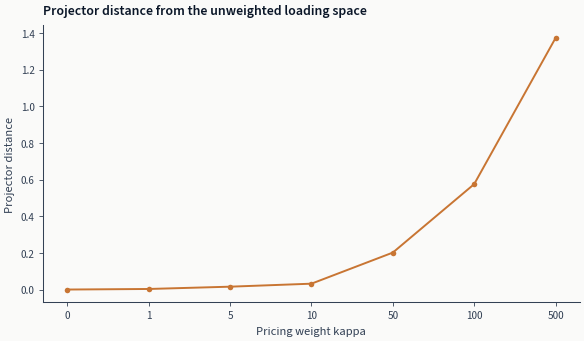

In [11]:
kappa_labels = [f"{result['kappa']:g}" for result in stage1_results]
pricing_shares = [result["pricing_share"] for result in stage1_results]
reconstruction_shares = [result["reconstruction_share"] for result in stage1_results]
projector_distances = [result["projector_distance"] for result in stage1_results]
positions = np.arange(len(KAPPAS))

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], sharex=True, constrained_layout=True)
axes[0].plot(positions, pricing_shares, marker="o", color=COLORS["blue"])
axes[0].set_ylabel("Training mean fit")
add_message_title(axes[0], "Training mean fit against pricing weight")
axes[1].plot(positions, reconstruction_shares, marker="o", color=COLORS["amber"])
axes[1].set_ylabel("Evaluation reconstruction share")
axes[1].set_xlabel("Pricing weight kappa")
axes[1].set_xticks(positions, kappa_labels)
add_message_title(axes[1], "Evaluation reconstruction share against pricing weight")
show_with_alt(
    fig,
    "Two stacked panels sharing a horizontal axis of pricing weight kappa, drawn at "
    "equal spacing rather than to scale. The upper plots how well the fitted factors "
    "represent the training mean; the lower plots the share of raw evaluation return "
    "energy they reconstruct, uncentered so the mean component counts. Both vertical "
    "axes are auto-scaled to their own data, so the lower panel magnifies a range of "
    "well under one percentage point.",
)
print(
    f"Evaluation reconstruction share ranges {min(reconstruction_shares):.4f} to "
    f"{max(reconstruction_shares):.4f} across the kappa grid; training mean fit ranges "
    f"{min(pricing_shares):.4f} to {max(pricing_shares):.4f}"
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
ax.plot(positions, projector_distances, marker="o", color=COLORS["copper"])
ax.set_ylabel("Projector distance")
ax.set_xlabel("Pricing weight kappa")
ax.set_xticks(positions, kappa_labels)
add_message_title(ax, "Projector distance from the unweighted loading space")
show_with_alt(
    fig,
    "A marked line of projector distance against pricing weight kappa, with kappa at "
    "equal spacing rather than to scale. The distance measures how far the fitted "
    "loading subspace has rotated away from the one fitted at kappa of zero.",
)

## 4. Stage 2: update before forecasting

RP-PCA supplies a fixed loading map and a training factor history. At each
evaluation decision, projecting the current observed return produces the
latest realized factor. Stage 2 appends that factor and forecasts the next
one. No forecaster generates an unattended multi-step path.

In [12]:
def expanding_mean_forecast(history: np.ndarray) -> np.ndarray:
    """Forecast the next factor vector with its expanding historical mean."""
    return history.mean(axis=0)

In [13]:
def ar1_forecast(history: np.ndarray) -> np.ndarray:
    """Refit one AR(1) per factor and forecast from the current realization."""
    forecasts = np.empty(history.shape[1])
    for factor in range(history.shape[1]):
        design = np.column_stack([np.ones(len(history) - 1), history[:-1, factor]])
        coefficients = np.linalg.lstsq(design, history[1:, factor], rcond=None)[0]
        forecasts[factor] = coefficients[0] + coefficients[1] * history[-1, factor]
    return forecasts

In [14]:
def ewma_forecast(
    history: np.ndarray,
    half_life: int = EWMA_HALF_LIFE,
) -> np.ndarray:
    """Forecast with an exponentially weighted mean of available factors."""
    ages = np.arange(len(history) - 1, -1, -1)
    weights = np.exp(-np.log(2) * ages / half_life)
    weights /= weights.sum()
    return weights @ history

In [15]:
def walk_forward_factor_forecasts(
    training_history: np.ndarray,
    current_factors: np.ndarray,
) -> dict[str, np.ndarray]:
    """Append each observable current factor, then forecast the following factor."""
    forecasters = {
        "Expanding mean": expanding_mean_forecast,
        "AR(1)": ar1_forecast,
        "EWMA": ewma_forecast,
    }
    forecasts = {name: np.empty_like(current_factors) for name in forecasters}
    history = training_history.copy()
    for step, current_factor in enumerate(current_factors):
        history = np.vstack([history, current_factor])
        for name, forecaster in forecasters.items():
            forecasts[name][step] = forecaster(history)
    return forecasts

In [16]:
focus_model = stage1_models[FOCUS_KAPPA]
current_factors = decision_returns @ focus_model["loadings"]
factor_forecasts = walk_forward_factor_forecasts(
    focus_model["factors"],
    current_factors,
)
for name, values in factor_forecasts.items():
    print(f"{name}: shape={values.shape}, first forecast={np.round(values[0], 6).tolist()}")

Expanding mean: shape=(1433, 5), first forecast=[0.002592, 0.000415, 0.00023, 0.000146, -0.000145]
AR(1): shape=(1433, 5), first forecast=[-0.000351, -0.000736, -0.00052, 0.000426, 0.000907]
EWMA: shape=(1433, 5), first forecast=[0.004831, 0.001176, 0.000205, -5.7e-05, -0.001266]


## 5. Stage 3: map and evaluate next-day returns

The static loadings map each factor-premium forecast back to 59 ETF return
forecasts. MSE uses the zero-return forecast as the benchmark. Rank IC is
computed within each decision-time cross-section and averaged over time;
Newey-West inference allows for serial dependence in the daily IC series.

In [17]:
def map_asset_forecasts(factor_predictions: np.ndarray, loadings: np.ndarray) -> np.ndarray:
    """Map factor-premium forecasts through the fixed loading matrix."""
    return factor_predictions @ loadings.T

In [18]:
def as_long_panel(
    predictions: np.ndarray,
    realized_returns: np.ndarray,
    timestamps: np.ndarray,
) -> pl.DataFrame:
    """Create a canonical decision-time panel for cross-sectional metrics."""
    n_periods, n_assets = predictions.shape
    return pl.DataFrame(
        {
            "timestamp": np.repeat(timestamps, n_assets),
            "symbol": np.tile(symbols, n_periods),
            "prediction": predictions.ravel(),
            "forward_return": realized_returns.ravel(),
        }
    )

In [19]:
def evaluate_forecast(
    name: str,
    predictions: np.ndarray,
    realized_returns: np.ndarray,
    timestamps: np.ndarray,
    seed: int,
) -> dict[str, float | str]:
    """Compute zero-benchmark MSE and HAC uncertainty for per-time rank IC."""
    panel = as_long_panel(predictions, realized_returns, timestamps)
    ic_frame = cross_sectional_ic_series(
        panel,
        panel,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    uncertainty = compute_ic_uncertainty(
        ic_frame,
        horizon=1,
        n_boot=N_BOOTSTRAP,
        seed=seed,
    )
    model_mse = float(np.mean((realized_returns - predictions) ** 2))
    zero_mse = float(np.mean(realized_returns**2))
    return {
        "name": name,
        "mse_ratio": model_mse / zero_mse,
        "r2_zero": 1.0 - model_mse / zero_mse,
        "mean_ic": uncertainty["mean_ic"],
        "ci_low": uncertainty["ci_hac_lower"],
        "ci_high": uncertainty["ci_hac_upper"],
        "p_hac": uncertainty["p_hac"],
    }

In [20]:
forecast_results = []
asset_forecasts = {}
for index, (name, factor_prediction) in enumerate(factor_forecasts.items()):
    predictions = map_asset_forecasts(factor_prediction, focus_model["loadings"])
    asset_forecasts[name] = predictions
    result = evaluate_forecast(
        name,
        predictions,
        target_returns,
        decision_timestamps,
        SEED + index,
    )
    forecast_results.append(result)
    print(
        f"{name}: MSE ratio={result['mse_ratio']:.5f}, "
        f"IC={result['mean_ic']:.4f} "
        f"[{result['ci_low']:.4f}, {result['ci_high']:.4f}], "
        f"HAC p={result['p_hac']:.3f}"
    )

Expanding mean: MSE ratio=0.99950, IC=0.0136 [-0.0032, 0.0305], HAC p=0.113


AR(1): MSE ratio=0.98877, IC=0.0226 [0.0057, 0.0394], HAC p=0.009


EWMA: MSE ratio=1.00565, IC=0.0043 [-0.0106, 0.0191], HAC p=0.573


Each interval is around that one forecaster's mean IC, and what it settles is whether
that forecaster's mean is distinguishable from zero. It says nothing about the gap
between two of them: the three IC series run over the same evaluation dates and the
same returns, so the uncertainty in a difference depends on how the two series covary,
which needs the paired daily difference and is not computed here. An IC can also be
statistically nonzero while the squared-error forecast remains economically
indistinguishable from zero at a daily horizon.

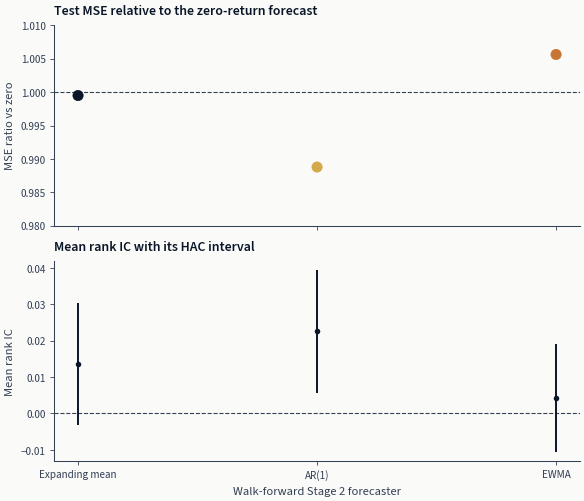

In [21]:
names = [result["name"] for result in forecast_results]
mse_ratios = np.array([result["mse_ratio"] for result in forecast_results])
mean_ics = np.array([result["mean_ic"] for result in forecast_results])
ci_low = np.array([result["ci_low"] for result in forecast_results])
ci_high = np.array([result["ci_high"] for result in forecast_results])
colors = ml4t_palette(len(names), categorical=True)

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], sharex=True, constrained_layout=True)
axes[0].scatter(names, mse_ratios, color=colors, s=55)
zero_line(axes[0], at=1.0)
axes[0].set_ylabel("MSE ratio vs zero")
axes[0].set_ylim(min(mse_ratios.min() - 0.004, 0.98), max(mse_ratios.max() + 0.004, 1.01))
add_message_title(axes[0], "Test MSE relative to the zero-return forecast")
errors = np.vstack([mean_ics - ci_low, ci_high - mean_ics])
axes[1].errorbar(names, mean_ics, yerr=errors, fmt="o", color=COLORS["blue"], capsize=4)
zero_line(axes[1])
axes[1].set_ylabel("Mean rank IC")
axes[1].set_xlabel("Walk-forward Stage 2 forecaster")
add_message_title(axes[1], "Mean rank IC with its HAC interval")
show_with_alt(
    fig,
    "Two stacked panels sharing a horizontal axis of Stage 2 forecaster. The upper "
    "marks each forecaster's test MSE as a ratio to the zero-return forecast, against a "
    "dashed line at one, on an axis spanning a few percentage points around that line. "
    "The lower plots each forecaster's mean rank IC as a point with a HAC interval, "
    "against a dashed line at zero.",
)

## 6. Takeaways

1. **RP-PCA changes Stage 1.** It rotates the PCA loading space toward the
   training mean vector while leaving the forecasting and mapping interfaces
   unchanged.
2. **Pricing fit and covariance fit are different objectives.** Here the
   training mean fit rises with $\kappa$ while evaluation reconstruction stays
   nearly flat; the sweep does not choose a weight on evaluation results.
3. **Missing is not zero.** Restricting eligibility to the 59 ETFs with
   complete training histories removes thousands of pre-inception pseudo-zeros.
4. **Walk-forward timing uses current information once.** Each observed factor
   updates history before the following day's premium is forecast.
5. **The figure says which forecasters clear zero, not which one is best.** The MSE
   panel is on an axis spanning a couple of percentage points either side of the
   benchmark, so a visible gap there is a small effect. The IC panel's intervals each
   ask whether that forecaster's mean IC is distinguishable from zero, and reading a
   ranking off them is the mistake the panel invites: separating two forecasters needs
   the interval on their paired daily difference, and overlapping individual intervals
   do not settle it either way. Whatever the run shows, this universe is curated and
   cannot support a survivorship-free strategy claim.